In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

## Load the dataframe

In [4]:
df = pd.read_csv("paper_results.tsv", sep="\t")

In [5]:
df

,modality,encoder_name,dataset,training_strategy,macro_f1,lower_ci,upper_ci,shots,training_time,training_params
0,audio,laion/clap-htsat-fused,digit,zs,1.818733,1.818182,1.819560,0,0.000000,0
1,audio,laion/clap-htsat-fused,emotion,zs,9.230989,7.488276,10.784050,0,0.000000,0
2,audio,laion/clap-htsat-fused,gender,zs,50.840270,49.932236,51.681711,0,0.000000,0
3,audio,laion/clap-htsat-fused,genre,zs,38.961020,35.384554,42.538442,0,0.000000,0
4,audio,laion/clap-htsat-fused,native,zs,4.780202,4.761905,4.816777,0,0.000000,0
5,audio,laion/clap-htsat-fused,digit,lt,64.404457,63.415643,65.276076,512,3.416178,5120
6,audio,laion/clap-htsat-fused,digit,lora,97.103289,96.703114,97.517801,512,7233.851645,146442
7,audio,laion/clap-htsat-fused,digit,logistic_regression,49.524212,44.831631,53.913886,512,0.235497,5130
8,audio,laion/clap-htsat-fused,emotion,lt,55.224978,51.512456,58.800261,512,3.480178,4096
9,audio,laion/clap-htsat-fused,emotion,lora,60.616952,56.608254,64.357227,512,5836.463521,145416


### Comparison of Zero-Shot and Label-Tuned Sub-1B Encoders with Jev

In [9]:
text_df = df[
    (df["modality"] == "text") &
    (df["training_strategy"].isin(["zs", "lt"]))
][["encoder_name", "dataset", "training_strategy", "shots", "macro_f1"]]

# Convert shots to a numeric sorting key.
# "all" goes last.
text_df["shots_sort"] = pd.to_numeric(
    text_df["shots"], errors="coerce"
).fillna(float("inf"))

pivot_df = (
    text_df
    .pivot(
        index=["encoder_name", "training_strategy", "shots", "shots_sort"],
        columns="dataset",
        values="macro_f1"
    )
    .sort_index(level="shots_sort")
    .droplevel("shots_sort")
)

pivot_df.style.highlight_max(
    axis=0,
    props="font-weight: bold;"
)

,,dataset,domain,emotion,hate,intent,rte3,sentiment,tweet-topic
encoder_name,training_strategy,shots,,,,,,,
Qwen/Qwen3-Embedding-0.6B,zs,0,81.298512,44.759070,54.897421,25.370091,28.609941,57.052590,51.707400
jev,zs,0,93.652862,51.536335,89.376889,66.242903,80.271990,64.366826,70.120881
microsoft/harrier-oss-v1-0.6b,zs,0,79.584830,52.415711,55.488434,25.232941,48.964954,59.874685,54.168601
microsoft/harrier-oss-v1-270m,zs,0,81.654273,55.044409,55.716768,22.116610,32.140467,46.815261,47.754472
Qwen/Qwen3-Embedding-0.6B,lt,8,86.403678,50.424903,57.750275,41.729961,38.793294,59.476543,62.430461
microsoft/harrier-oss-v1-0.6b,lt,8,91.428995,39.692069,53.704499,45.514833,39.236463,50.426060,62.931986
microsoft/harrier-oss-v1-270m,lt,8,90.557523,40.511819,58.322223,41.361783,37.558478,49.171579,62.563816
Qwen/Qwen3-Embedding-0.6B,lt,64,91.784744,53.905705,69.883863,55.325709,39.465689,62.798736,68.198146
microsoft/harrier-oss-v1-0.6b,lt,64,94.443126,57.960035,75.884190,61.403771,53.889142,63.221338,70.078091


### Boxplots of zs vs. random vs. majority
To show that adaptation is generally needed.

In [ ]:
modalities = ["text", "audio", "image", "video"]

for modality in modalities:
    sub = df[df["modality"] == modality]

    # Average across encoders for each dataset, so the performance
    # of the zero-shot approach is the mean across encoders.
    zs = (
        sub[sub["training_strategy"].str.contains("zs", case=False, na=False)]
        .groupby("dataset")["macro_f1"]
        .mean()
        .rename("zs")
    )

    random = (
        sub[
            sub["encoder_name"].str.contains("stratified", case=False, na=False)
        ]
        .set_index("dataset")["macro_f1"]
        .rename("random")
    )

    majority = (
        sub[
            sub["encoder_name"].str.contains(
                "most_frequent", case=False, na=False
            )
        ]
        .set_index("dataset")["macro_f1"]
        .rename("majority")
    )

    comp = zs.to_frame().join(random).join(majority).dropna()

    stat, p = wilcoxon(comp["zs"], comp["random"], alternative="greater")
    print(f"{modality}: ZS > Random: p={p:.4f}")

    stat, p = wilcoxon(comp["zs"], comp["majority"], alternative="greater")
    print(f"{modality}: ZS > Majority: p={p:.4f}")


text: ZS > Random: p=0.0078
text: ZS > Majority: p=0.0078
audio: ZS > Random: p=0.3125
audio: ZS > Majority: p=0.1562
image: ZS > Random: p=0.6875
image: ZS > Majority: p=0.1875
video: ZS > Random: p=0.3125
video: ZS > Majority: p=0.0625


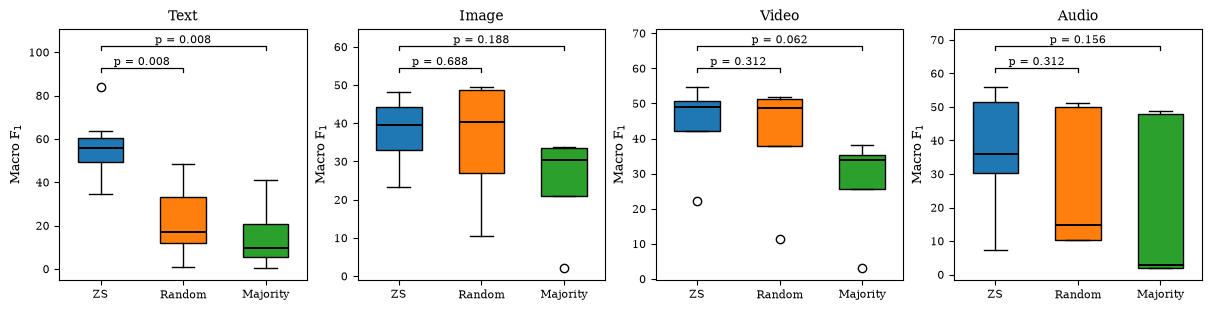

In [11]:
# Code generated with ChatGPT (september 2026) and modified by the author.

# -----------------------------
# Matplotlib settings for papers
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

colors = ["tab:blue", "tab:orange", "tab:green"]
modalities = ["text", "image", "video", "audio"]


# Wilcoxon test p-values
pvals = {
    "text":   {"random": 0.0078, "majority": 0.0078},
    "image":  {"random": 0.6875, "majority": 0.1875},
    "video":  {"random": 0.3125, "majority": 0.0625},
    "audio":  {"random": 0.3125, "majority": 0.1562},
}


def p_to_text(p):
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


def significance_bar(ax, x1, x2, y, h, text):
    """Draw a significance bar."""
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        lw=0.9,
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=8,
    )


# ----------------------------------------------------
# Figure size:
# 6.8 x 5.2 inches ≈ 17.3 x 13.2 cm (double-column)
# ----------------------------------------------------
fig, axes = plt.subplots(
    1,
    4,
    figsize=(12, 3),
    constrained_layout=True,
)

axes = axes.flatten()

for ax, modality in zip(axes, modalities):

    sub = df[df["modality"] == modality]

    if sub.empty:
        ax.set_title(f"{modality.capitalize()} (no data)")
        ax.axis("off")
        continue

    zs = (
        sub[sub["training_strategy"].str.contains("zs", case=False, na=False)]
        .groupby("dataset")["macro_f1"]
        .mean()
        .rename("zs")
        .dropna()
        .to_numpy()
    )

    random = sub[
        sub["encoder_name"].str.contains("stratified", case=False, na=False)
    ]["macro_f1"].dropna().to_numpy()

    majority = sub[
        sub["encoder_name"].str.contains("most_frequent", case=False, na=False)
    ]["macro_f1"].dropna().to_numpy()

    bp = ax.boxplot(
        [zs, random, majority],
        patch_artist=True,
        widths=0.55,
        tick_labels=["ZS", "Random", "Majority"],
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        boxprops=dict(linewidth=1),
    )

    # Color the boxes
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_title(modality.capitalize())
    ax.set_ylabel(r"Macro F$_1$")

    # -----------------------------
    # Significance annotations
    # -----------------------------
    ymax = max(np.max(zs), np.max(random), np.max(majority))
    ymin = min(np.min(zs), np.min(random), np.min(majority))

    yrange = ymax - ymin
    if yrange == 0:
        yrange = 0.05

    offset = 0.08 * yrange
    h = 0.025 * yrange

    # ZS vs Random
    significance_bar(
        ax,
        1,
        2,
        ymax + offset,
        h,
        p_to_text(pvals[modality]["random"]),
    )

    # ZS vs Majority
    significance_bar(
        ax,
        1,
        3,
        ymax + 2.5 * offset,
        h,
        p_to_text(pvals[modality]["majority"]),
    )

    # Leave room for annotations
    ax.set_ylim(top=ymax + 4 * offset)

# -----------------------------
# Single legend for the figure
# -----------------------------
handles = [
    Patch(facecolor=c, edgecolor="black", label=l)
    for c, l in zip(colors, ["ZS", "Random", "Majority"])
]


# Save as vector graphics for LaTeX
plt.savefig(
    "zs-vs-baselines-row.pdf",
    bbox_inches="tight",
    dpi=600,
)

### Average improvement of LT over ZS with increasing shots

Shows how LT adaptation improves ZS across shots. The improvement do not come from a given encoder, it improves across encoders.
Trend: the better the encoder in zs, the smaller gains, with the exception of the image modality. Still, improvements are around 20 points of Macro F1 on average.

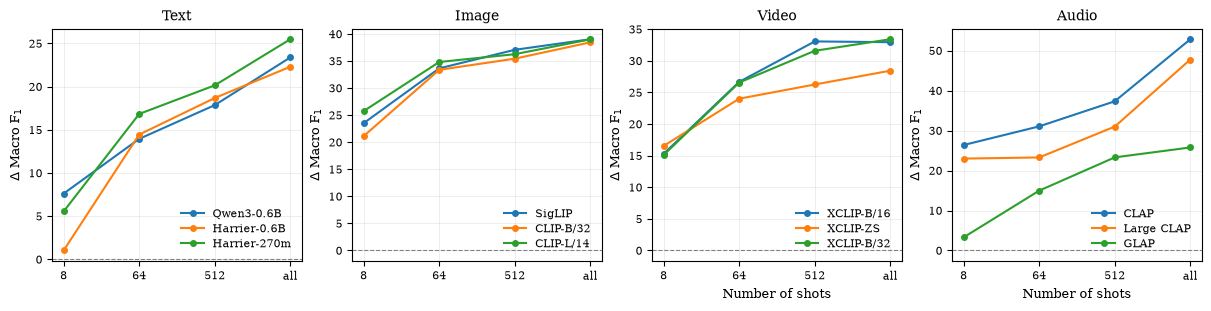

In [12]:
# Code generated by ChatGPT (september 2026) and modified by the author.

# -----------------------------
# Matplotlib settings for papers
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------------------
# Short labels for the legend
# ---------------------------------------
encoder_labels = {
    # Text
    "Qwen/Qwen3-Embedding-0.6B": "Qwen3-0.6B",
    "microsoft/harrier-oss-v1-0.6b": "Harrier-0.6B",
    "microsoft/harrier-oss-v1-270m": "Harrier-270m",

    # Image
    "google/siglip-so400m-patch14-384": "SigLIP",
    "openai/clip-vit-base-patch32": "CLIP-B/32",
    "openai/clip-vit-large-patch14": "CLIP-L/14",

    # Video
    "microsoft/xclip-base-patch16": "XCLIP-B/16",
    "microsoft/xclip-base-patch16-zero-shot": "XCLIP-ZS",
    "microsoft/xclip-base-patch32": "XCLIP-B/32",

    # Audio
    "laion/clap-htsat-fused": "CLAP",
    "laion/larger_clap_music_and_speech": "Large CLAP",
    "mispeech/GLAP": "GLAP",
}

# ---------------------------------------
# Prepare the data
# ---------------------------------------

zs_df = df[df["training_strategy"] == "zs"]
lt_df = df[df["training_strategy"] == "lt"]

zs_baseline = (
    zs_df.groupby(
        ["modality", "encoder_name", "dataset"]
    )["macro_f1"]
    .mean()
    .reset_index()
    .rename(columns={"macro_f1": "zs_macro_f1"})
)

merged = lt_df.merge(
    zs_baseline,
    on=["modality", "encoder_name", "dataset"],
    how="inner",
)

merged["improvement"] = (
    merged["macro_f1"] - merged["zs_macro_f1"]
)

merged["shots"] = merged["shots"].astype(str)

avg_improvement = (
    merged.groupby(
        ["modality", "encoder_name", "shots"]
    )["improvement"]
    .mean()
    .reset_index()
)

shot_order = ["8", "64", "512", "all"]
shot_pos = {s: i for i, s in enumerate(shot_order)}

avg_improvement = avg_improvement[
    avg_improvement["shots"].isin(shot_order)
]

avg_improvement["shot_pos"] = (
    avg_improvement["shots"].map(shot_pos)
)

modalities = ["text", "image", "video", "audio"]

# ---------------------------------------
# Plot
# ---------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(12, 3),
    constrained_layout=True,
)

axes = axes.flatten()

for ax, modality in zip(axes, modalities):

    sub = avg_improvement[
        avg_improvement["modality"] == modality
    ]

    if sub.empty:
        ax.set_title(f"{modality.capitalize()} (no data)")
        ax.axis("off")
        continue

    for encoder_name, group in sub.groupby("encoder_name"):

        group = group.sort_values("shot_pos")

        label = encoder_labels.get(
            encoder_name,
            encoder_name,
        )

        ax.plot(
            group["shot_pos"],
            group["improvement"],
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=label,
        )

    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=0.8,
    )

    ax.set_title(modality.capitalize())

    ax.set_ylabel(r"$\Delta$ Macro F$_1$")

    ax.set_xticks(range(len(shot_order)))
    ax.set_xticklabels(shot_order)

    ax.grid(
        True,
        alpha=0.3,
        linewidth=0.5,
    )

    # Small legend inside each subplot
    ax.legend(
        loc="lower right",
        frameon=False,
        fontsize=8,
        handlelength=2,
        borderpad=0.5,
        labelspacing=0.3,
    )

# X labels only on bottom row
axes[2].set_xlabel("Number of shots")
axes[3].set_xlabel("Number of shots")

# ---------------------------------------
# Save
# ---------------------------------------

plt.savefig(
    "lt-improvement-over-zs-row.pdf",
    bbox_inches="tight",
)

### Radar plot of LT per dataset
Improvements don't come from a specific dataset, instead, they appear across datasets.

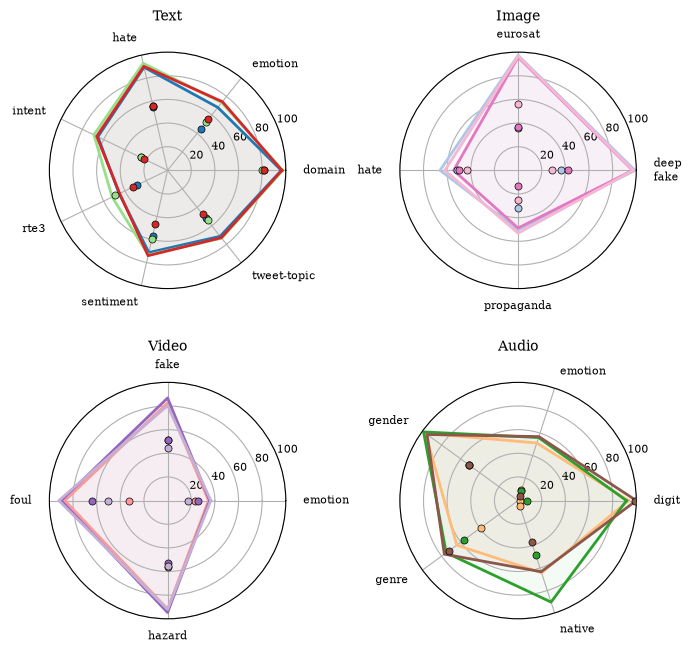

In [13]:
# -------------------------------------------------------
# Matplotlib settings
# -------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------------------------------------------
# Short encoder names
# -------------------------------------------------------
df = df.copy()
df["shots"] = df["shots"].astype(str)

modalities = ["text", "image", "video", "audio"]

# -------------------------------------------------------
# Consistent colors
# -------------------------------------------------------
all_encoders = sorted(df["encoder_name"].dropna().unique())

cmap = plt.get_cmap("tab10" if len(all_encoders) <= 10 else "tab20")

encoder_colors = {
    enc: cmap(i % cmap.N)
    for i, enc in enumerate(all_encoders)
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.8, 6.6),
    subplot_kw={"polar": True},
    constrained_layout=True,
)

axes = axes.flatten()

for ax, modality in zip(axes, modalities):

    sub = df[df["modality"] == modality]

    if sub.empty:
        ax.axis("off")
        continue

    tasks = sorted(sub["dataset"].dropna().unique())

    angles = np.linspace(
        0,
        2 * np.pi,
        len(tasks),
        endpoint=False,
    )

    angles_closed = np.concatenate([angles, [angles[0]]])

    # ---------------------------
    # LT (all shots)
    # ---------------------------
    full = sub[
        (sub["training_strategy"] == "lt")
        & (sub["shots"] == "all")
    ]

    pivot = (
        full.pivot_table(
            index="encoder_name",
            columns="dataset",
            values="macro_f1",
            aggfunc="mean",
        )
        .reindex(columns=tasks)
        .dropna(how="any")
    )

    # ---------------------------
    # Zero-shot
    # ---------------------------
    zs = (
        sub[sub["training_strategy"] == "zs"]
        .pivot_table(
            index="encoder_name",
            columns="dataset",
            values="macro_f1",
            aggfunc="mean",
        )
        .reindex(columns=tasks)
    )

    encoder_names = []

    for encoder, row in pivot.iterrows():

        color = encoder_colors[encoder]

        values = row.values.astype(float)
        values = np.concatenate([values, [values[0]]])

        ax.plot(
            angles_closed,
            values,
            linewidth=2,
            color=color,
        )

        # Comment this out if you prefer no fills
        ax.fill(
            angles_closed,
            values,
            color=color,
            alpha=0.05,
        )

        if encoder in zs.index:

            zs_values = zs.loc[encoder].values.astype(float)

            mask = ~np.isnan(zs_values)

            ax.scatter(
                angles[mask],
                zs_values[mask],
                color=color,
                edgecolor="black",
                linewidth=0.5,
                s=26,
                zorder=5,
            )

    # nicer task labels
    tasks_display = [
        t.replace("deepfake", "deep\nfake")
        for t in tasks
    ]

    ax.set_xticks(angles)
    ax.set_xticklabels(tasks_display)

    for label, angle in zip(ax.get_xticklabels(), angles):

        angle_deg = np.degrees(angle) % 360

        if angle_deg < 90 or angle_deg > 270:
            label.set_horizontalalignment("left")
        elif 90 < angle_deg < 270:
            label.set_horizontalalignment("right")
        else:
            label.set_horizontalalignment("center")

    ax.tick_params(axis="x", pad=2)

    ax.set_ylim(0, 100)

    # -----------------------------------------
    # Title + encoder names
    # -----------------------------------------

    ax.text(
        0.5,
        1.12,                # fixed height above every radar
        modality.capitalize(),
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
    )


plt.savefig(
    "radar-lt-performance-per-task-encoder.pdf",
    bbox_inches="tight",
)


plt.show()

### LT vs LoRA
Compare the average performance of LT, Logistic Regression, and LoRA across different numbers of shots, averaging over all encoders and tasks. For each modality, plot macro-f1 and training time, showing the number of trainable parameters.

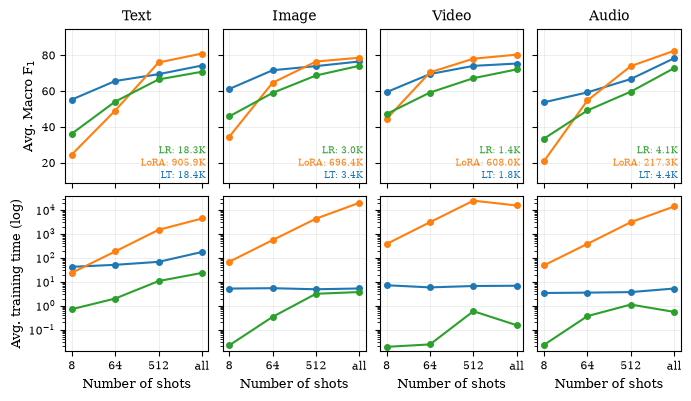

In [15]:
# Code generated by ChatGPT (september 2026) and modified by the author.

# -----------------------------
# Matplotlib settings for papers
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "axes.titleweight": "normal",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

df = df.copy()
df["shots"] = df["shots"].astype(str)

modalities = ["text", "image", "video", "audio"]

strategies = [
    "lt",
    "lora",
    "logistic_regression",
]

strategy_labels = {
    "lt": "Label Tuning",
    "lora": "LoRA",
    "logistic_regression": "LR",
}

strategy_colors = {
    "lt": "tab:blue",
    "lora": "tab:orange",
    "logistic_regression": "tab:green",
}

shot_order = ["8", "64", "512", "all"]
shot_pos = {s: i for i, s in enumerate(shot_order)}

sub_df = df[
    df["training_strategy"].isin(strategies)
    & df["shots"].isin(shot_order)
]

# -------------------------------------------------------
# Average over encoders and datasets
# -------------------------------------------------------

avg_df = (
    sub_df.groupby(
        ["modality", "training_strategy", "shots"]
    )
    .agg(
        macro_f1=("macro_f1", "mean"),
        training_time=("training_time", "mean"),
        training_params=("training_params", "mean"),
    )
    .reset_index()
)

avg_df["shot_pos"] = avg_df["shots"].map(shot_pos)

params_summary = (
    avg_df.groupby(
        ["modality", "training_strategy"]
    )["training_params"]
    .mean()
    .to_dict()
)


def human_format(num):
    if num is None or pd.isna(num):
        return "N/A"

    num = float(num)

    magnitude = 0
    while abs(num) >= 1000 and magnitude < 4:
        magnitude += 1
        num /= 1000

    return f"{num:.1f}{['', 'K', 'M', 'B', 'T'][magnitude]}"


metrics = [
    ("macro_f1", r"Avg. Macro F$_1$"),
    ("training_time", "Avg. training time (log)"),
]


def needs_log_scale(values):
    values = values[values > 0]
    if values.empty:
        return False
    return values.max() / values.min() > 30


log_flags = {
    metric: needs_log_scale(avg_df[metric].dropna())
    for metric, _ in metrics
}

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

fig, axes = plt.subplots(
    len(metrics),
    len(modalities),
    figsize=(6.8, 3.9),
    constrained_layout=True,
)

for r, (metric, ylabel) in enumerate(metrics):

    for c, modality in enumerate(modalities):

        ax = axes[r, c]

        msub = avg_df[
            avg_df["modality"] == modality
        ]

        if msub.empty:
            ax.axis("off")
            continue

        for strat in strategies:

            s = (
                msub[
                    msub["training_strategy"] == strat
                ]
                .set_index("shot_pos")
                .reindex(range(len(shot_order)))
            )

            valid = s[metric].notna()

            ax.plot(
                s.index[valid],
                s.loc[valid, metric],
                marker="o",
                markersize=4,
                linewidth=1.5,
                color=strategy_colors[strat],
                label=strategy_labels[strat],
            )

        if log_flags[metric]:
            ax.set_yscale("log")

        if r == 0:
            ax.set_title(modality.capitalize())

        ax.set_xticks(range(len(shot_order)))
        ax.set_xticklabels(shot_order)

        ax.grid(
            True,
            alpha=0.3,
            linewidth=0.5,
        )

        # only left column gets y-labels
        if c == 0:
            ax.set_ylabel(ylabel)
        else:
            ax.tick_params(labelleft=False)

        # only bottom row gets x-labels
        if r == len(metrics) - 1:
            ax.set_xlabel("Number of shots")
        else:
            ax.tick_params(labelbottom=False)

        # ---------------------------------------------------
        # Parameter counts (top row only)
        # ---------------------------------------------------

        if r == 0:

            lt_p = human_format(
                params_summary.get((modality, "lt"))
            )
            lora_p = human_format(
                params_summary.get((modality, "lora"))
            )
            lr_p = human_format(
                params_summary.get((modality, "logistic_regression"))
            )

            ax.text(
                0.98,
                0.02,
                f"LT: {lt_p}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=6.5,
                color=strategy_colors["lt"],
            )

            ax.text(
                0.98,
                0.10,
                f"LoRA: {lora_p}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=6.5,
                color=strategy_colors["lora"],
            )

            ax.text(
                0.98,
                0.18,
                f"LR: {lr_p}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=6.5,
                color=strategy_colors["logistic_regression"],
            )

# -------------------------------------------------------
# Shared y-limits within each metric
# -------------------------------------------------------

for r, (metric, _) in enumerate(metrics):

    row_axes = [
        axes[r, c]
        for c in range(len(modalities))
        if axes[r, c].has_data()
    ]

    vals = avg_df[metric].dropna()

    if log_flags[metric]:
        vals = vals[vals > 0]

    if vals.empty:
        continue

    vmin = vals.min()
    vmax = vals.max()

    if log_flags[metric]:
        lo = vmin / 1.5
        hi = vmax * 1.5
    else:
        pad = max(
            (vmax - vmin) * 0.20,
            vmax * 0.02 if vmax else 0.01,
        )
        lo = vmin - pad
        hi = vmax + pad

    for ax in row_axes:
        ax.set_ylim(lo, hi)

# -------------------------------------------------------
# Shared legend
# -------------------------------------------------------

handles = [
    Line2D(
        [0],
        [0],
        color=strategy_colors[s],
        marker="o",
        markersize=4,
        linewidth=1.5,
        label=strategy_labels[s],
    )
    for s in strategies
]

# -------------------------------------------------------
# Save
# -------------------------------------------------------

plt.savefig(
    "lt-vs-lora-vs-lr.pdf",
    bbox_inches="tight",
)

plt.show()